In [ ]:
!pip install -q datasets segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
import torch
import cv2
import numpy as np
from pathlib import Path
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = load_dataset("EduardoPacheco/FoodSeg103")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4983 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2135 [00:00<?, ? examples/s]

In [ ]:
IMAGE_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
def transform_fn(examples):
    processed_images = []
    processed_masks = []

    for img, label in zip(examples["image"], examples["label"]):
        # Convert PIL to NumPy
        img_np = np.array(img.convert("RGB"))
        mask_np = np.array(label)

        # Apply Albumentations
        # FoodSeg103 masks are usually 2D (H, W) integers
        augmented = train_transform(image=img_np, mask=mask_np)

        processed_images.append(augmented["image"])
        processed_masks.append(augmented["mask"].long())

    return {"pixel_values": processed_images, "labels": processed_masks}

dataset["train"].set_transform(transform_fn)
dataset["validation"].set_transform(transform_fn)

# 4. DataLoader
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }

train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(dataset["validation"], batch_size=16, collate_fn=collate_fn)

In [ ]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=104
).cuda()

# 6. Loss and Optimizer

criterion = smp.losses.DiceLoss(mode='multiclass')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Simple Training Step Example
# batch = next(iter(train_loader))
# outputs = model(batch['pixel_values'].cuda())
# loss = criterion(outputs, batch['labels'].cuda())

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
from tqdm.auto import tqdm

def train_model(epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        # Progress bar for the epoch
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in pbar:
            # Move to GPU (T4 in Colab)
            images = batch['pixel_values'].to(device)
            masks = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # DiceLoss expects (batch, classes, H, W) vs (batch, H, W)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1} Avg Loss: {train_loss/len(train_loader):.4f}")

# Start training
train_model(epochs=5) # Start with 3 to test speed

Epoch 1/5:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 1 Avg Loss: 0.3176


Epoch 2/5:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 2 Avg Loss: 0.3026


Epoch 3/5:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 3 Avg Loss: 0.2896


Epoch 4/5:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 4 Avg Loss: 0.2793


Epoch 5/5:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 5 Avg Loss: 0.2687


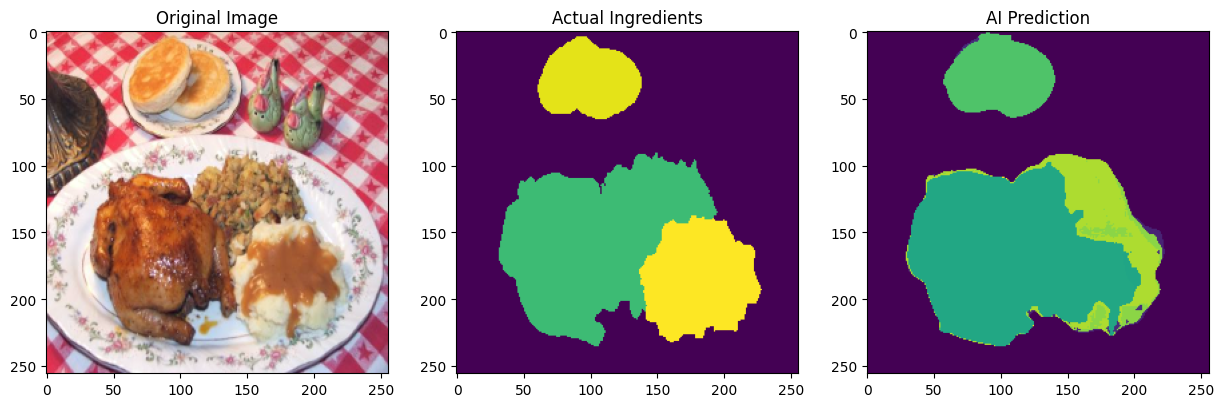

In [ ]:
import matplotlib.pyplot as plt

def visualize_prediction(dataset_split="validation", index=0):
    model.eval()

    # Get a sample
    sample = dataset[dataset_split][index]
    image_tensor = sample['pixel_values'].unsqueeze(0).to(device)
    gt_mask = sample['labels'].numpy()

    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        # Use argmax to get the class with the highest probability per pixel
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Show Original (Need to un-normalize for proper colors)
    img_show = sample['pixel_values'].permute(1, 2, 0).numpy()
    img_show = (img_show * 0.229) + 0.485 # Reverse normalization approx
    ax[0].imshow(np.clip(img_show, 0, 1))
    ax[0].set_title("Original Image")

    # Show Ground Truth
    ax[1].imshow(gt_mask)
    ax[1].set_title("Actual Ingredients")

    # Show Model Prediction
    ax[2].imshow(pred_mask)
    ax[2].set_title("AI Prediction")

    plt.show()

# Run it on the first image in validation
visualize_prediction(index=10)